In [ ]:
import numpy as np
import pandas as pd
from iotbr import tru as tru
from iotbr import io_system as ios
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [39]:
# 1) importar dados exportaco BRA=>USA
exp = pd.read_csv('dados_exportacao_classificados_em_tru68.csv', sep=';', dtype={
    'Ano': str,
    'atividade_cod': str,
    'atividade_desc': str,
    'Valor RS$ FOB': float
})

# 1.1) agrupar e excluir outras colunas
exp_tru = exp.groupby(['Ano', 'atividade_cod', 'atividade_desc'])['Valor RS$ FOB'].sum().reset_index()

# 1.2) transformar valores de exportação de BRL para milhoes de BRL para coincidir com dados da TRU
exp_tru['X_bens_serv_usa'] = exp_tru['Valor RS$ FOB'] / 1000000
exp_tru = exp_tru[['Ano','atividade_cod','X_bens_serv_usa']]


In [ ]:
# 2) simular choque de exportação para os EUA
# sistema aberto
# considera apenas o efeito direto
# existem três tipos de efeitos: direto, indireto e induzido

def choque_usa(ano, exp_tru):
    # 2.1) sistema e inversa de Leontief
    sys = ios.system(ano, '68', 't')
    L = sys.mL

    # 2.2) vetor de exportações totais por atividade (final demand: X_bens_serv)
    Yexp = sys.mY['X_bens_serv']              # index: "cod\nnome"
    idx = Yexp.index
    cod = idx.str.split('\n').str[0]

    base = pd.DataFrame({'atividade_cod': cod, 'Yexp': Yexp.values}, index=idx)

    # 2.3) exportações para EUA no ano (agregando se vierem repetidas)
    usa = (exp_tru.loc[exp_tru['Ano'] == ano, ['atividade_cod', 'X_bens_serv_usa']]
                 .groupby('atividade_cod', as_index=False).sum())

    df = (base.reset_index()
               .merge(usa, on='atividade_cod', how='left')
               .fillna({'X_bens_serv_usa': 0.0}))

    # 2.4) Choque na demanda final: zerar EUA => ΔY = -X_bens_serv_usa
    dY = pd.Series(-df['X_bens_serv_usa'].values, index=idx, name='dY')

    # 2.5) Efeito total (direto + indireto): ΔX = L · ΔY
    dX = L @ dY.values

    # 2.6) VBP de referência e alinhamento
    X0 = tru.read_var(ano, '68', 'VA_table', 't')['Valor da produção']
    X0 = X0.reindex(idx).values  # garante mesma ordem do ΔX

    # 2.7) DataFrame final (nível e %)
    out = pd.DataFrame({'atividade': idx, 'DX': dX, 'X0': X0})
    out['DX_pct'] = out['DX'] / out['X0']
    out['DX_pct_fmt'] = out['DX_pct'].map('{:.2%}'.format)

    return out[['atividade', 'DX_pct', 'DX_pct_fmt']]


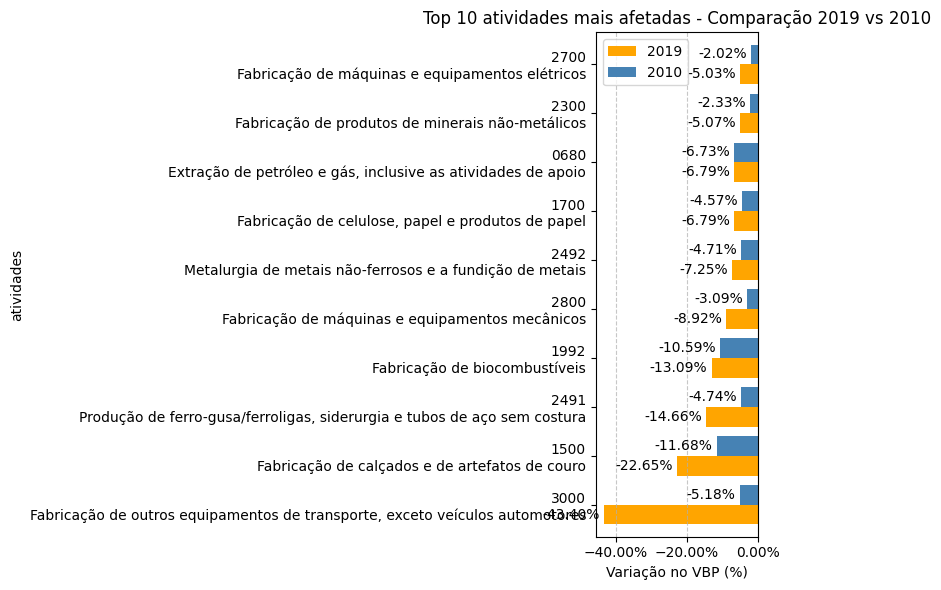

In [92]:
# 3) Plotar os resultados

# 3.1) Rodar função para os dois anos
vDX_2019 = choque_usa('2019', exp_tru)
vDX_2010 = choque_usa('2010', exp_tru)


# 3.2) Top 10 atividades mais afetadas em 2019
top10_sectors = vDX_2019.sort_values('DX_pct').head(10)['atividade']

# 3.3) ordenar e filtrar os dados para o plot
df_plot_num = pd.DataFrame({
    '2019': vDX_2019.set_index('atividade').loc[top10_sectors, 'DX_pct'],
    '2010': vDX_2010.set_index('atividade').loc[top10_sectors, 'DX_pct']
}).sort_values('2019')

df_plot_fmt = pd.DataFrame({
    '2019': vDX_2019.set_index('atividade').loc[top10_sectors, 'DX_pct_fmt'],
    '2010': vDX_2010.set_index('atividade').loc[top10_sectors, 'DX_pct_fmt']
}).loc[df_plot_num.index]

# 3.4) Plotar os dados
fig, ax = plt.subplots(figsize=(8, 6))
df_plot_num.plot(
    kind='barh',
    ax=ax,
    color=['orange', 'steelblue'],
    width=0.8
)

# 3.4.1) Rótulos das barras (DX_pct_fmt)
for container, labels in zip(ax.containers, df_plot_fmt.T.values):
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 3.4.2) Eixo X em porcentagem
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))

# 3.4.3) Títulos e grade
ax.set_xlabel('Variação no VBP (%)')
ax.set_ylabel('atividades')
ax.set_title('Top 10 atividades mais afetadas - Comparação 2019 vs 2010')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
